##Step 2: Data Collection

###Import Necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score
from pickle import dump
import warnings
warnings.filterwarnings('ignore')

###Load Dataset

In [ ]:
iris_data = load_iris()
iris_data


{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
print(iris_data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
iris_data_df = pd.DataFrame(iris_data.data,columns= iris_data['feature_names'])
iris_data_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


##Step 3: Data Understanding

In [ ]:
iris_data_df.shape

(150, 4)

In [ ]:
iris_data_df.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
iris_data_df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64


In [ ]:
iris_data_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


##Step 4: Data Preparation

In [ ]:
X = iris_data_df

In [ ]:
std_scaler = StandardScaler()
Scaled_X = std_scaler.fit_transform(X)
Scaled_X = pd.DataFrame(Scaled_X,columns=X.columns)
Scaled_X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [ ]:
Scaled_X.mean().round(4),Scaled_X.std().round(4)

(sepal length (cm)   -0.0
 sepal width (cm)    -0.0
 petal length (cm)   -0.0
 petal width (cm)    -0.0
 dtype: float64,
 sepal length (cm)    1.0034
 sepal width (cm)     1.0034
 petal length (cm)    1.0034
 petal width (cm)     1.0034
 dtype: float64)

##Step 5: Model Building

###Level 1: Build cluster Algorithm

In [ ]:
clusters = KMeans(n_clusters=3,random_state=15)
clusters

KMeans(n_clusters=3, random_state=15)

In [ ]:
clusters_new = clusters.fit(Scaled_X)
clusters_new.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0], dtype=int32)

In [ ]:
clusters_new.inertia_

140.90153181202444

###Finding the optimal number of clusters

In [ ]:
wcss = []
for i in range(1,11):
  kmeans_cluster = KMeans(n_clusters=i,random_state=51)
  kmeans_cluster.fit(Scaled_X)
  wcss.append(kmeans_cluster.inertia_)


In [ ]:
wcss

[600.0,
 222.36170496502302,
 140.03275277428654,
 114.62685984300724,
 91.69018971543906,
 81.98512085058611,
 72.38783437032762,
 63.4660115202921,
 55.73273941755984,
 47.53702734180288]

###Plot the Number of clusters vs WCSS to find optimal clusters

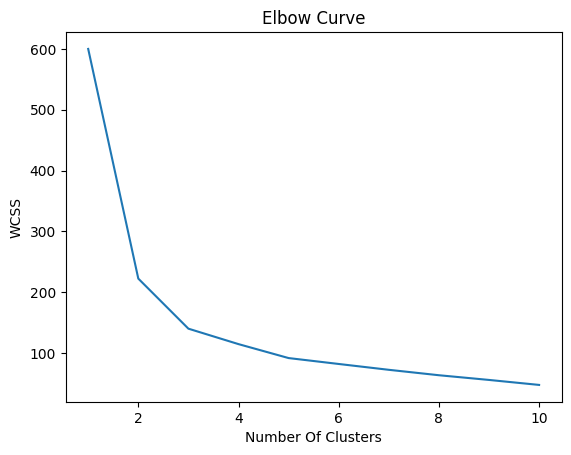

In [ ]:
plt.plot(range(1,11),wcss)
plt.title('Elbow Curve')
plt.xlabel('Number Of Clusters')
plt.ylabel('WCSS')
plt.show()

###Passing X as training

In [ ]:
clusters_X = KMeans(n_clusters=3,random_state=16)
clusters_X = clusters.fit(X)
clusters_X.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [ ]:
clusters_X.inertia_

78.85566582597727

###Finding the optimal number of clusters using X as training

In [ ]:
wcss = []
for i in range(1,11):
  kmeans_cluster = KMeans(n_clusters=i,random_state=51)
  kmeans_cluster.fit(X)
  wcss.append(kmeans_cluster.inertia_)

In [ ]:
wcss

[681.3705999999996,
 152.34795176035797,
 78.851441426146,
 57.265619047619055,
 49.86225000000001,
 45.59262151067325,
 38.18642670547844,
 32.99483463904516,
 28.989438215293497,
 27.3592001200554]

###Plot the Number of clusters vs WCSS to find optimal clusters

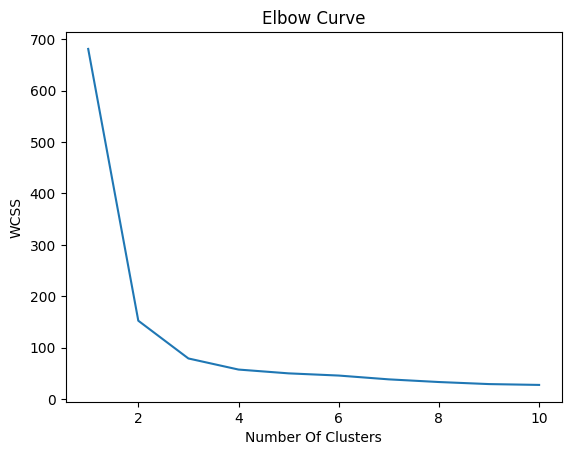

In [ ]:
plt.plot(range(1,11),wcss)
plt.title('Elbow Curve')
plt.xlabel('Number Of Clusters')
plt.ylabel('WCSS')
plt.show()

###By this Elbow curve, number of clusters=3 good to use for this dataset

###Level 2: Assigning Clusters to the dataset and perform some data mining operations

In [ ]:
iris_data_df['category'] = clusters_new.labels_
iris_data_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),category
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


In [ ]:
X['category'] = clusters_new.labels_
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),category
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


In [ ]:
X.groupby(by='category').agg(['mean'])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
,mean,mean,mean,mean
category,,,,
0,6.853846,3.076923,5.715385,2.053846
1,5.006000,3.428000,1.462000,0.246000
2,5.883607,2.740984,4.388525,1.434426


Species Identification based on Input Features Range


| Species         | Sepal Length | Sepal Width | Petal Length | Petal Width |
| --------------- | ------------ | ----------- | ------------ | ----------- |
| Iris Setosa     | 4.3–5.8      | 2.3–4.4     | **1.0–1.9**  | **0.1–0.6** |
| Iris Versicolor | 4.9–7.0      | 2.0–3.4     | **3.0–5.1**  | **1.0–1.8** |
| Iris Virginica  | 4.9–7.9      | 2.2–3.8     | **4.5–6.9**  | **1.4–2.5** |


In [ ]:
X.groupby(by='category').agg(['min','max'])

sepal length (cm)      sepal width (cm)      petal length (cm)       \
                       min  max              min  max               min  max   
category                                                                       
0                      6.1  7.9              2.5  3.8               4.7  6.9   
1                      4.3  5.8              2.3  4.4               1.0  1.9   
2                      4.9  6.8              2.0  3.4               3.0  5.1   

         petal width (cm)       
                      min  max  
category                        
0                     1.4  2.5  
1                     0.1  0.6  
2                     1.0  2.4

### Mapping the Category with Species Names

In [ ]:
cluster_names = {
    0:'Iris Virginica',
    1:'Iris Setosa',
    2:'Iris Versicolor'
}

In [ ]:
X['species'] = X['category'].map(cluster_names)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),category,species
0,5.1,3.5,1.4,0.2,1,Iris Setosa
1,4.9,3.0,1.4,0.2,1,Iris Setosa
2,4.7,3.2,1.3,0.2,1,Iris Setosa
3,4.6,3.1,1.5,0.2,1,Iris Setosa
4,5.0,3.6,1.4,0.2,1,Iris Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,Iris Virginica
146,6.3,2.5,5.0,1.9,2,Iris Versicolor
147,6.5,3.0,5.2,2.0,0,Iris Virginica
148,6.2,3.4,5.4,2.3,0,Iris Virginica


##Level 3: Apply Supervised Learning

##Model Training || Model Evaluation

In [ ]:
input_data = X.drop(columns=['category','species'])
output_data = X['category']
X_train,X_test,y_train,y_test = train_test_split(input_data,output_data,random_state=13,shuffle=True,stratify=output_data)
model = RandomForestClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print('Accuracy_score',round(accuracy_score(y_test,y_pred),4))
print('Precision_score',round(precision_score(y_test,y_pred,average='weighted'),4))
print('Recall_score',round(recall_score(y_test,y_pred,average ='weighted'),4))


Accuracy_score 0.9737
Precision_score 0.9753
Recall_score 0.9737
